# Time Complexity

## What T(n) Actually Measures

The lecture's key point: complexity is **not** about seconds on a stopwatch (that depends on your
CPU, RAM, language, etc. - "performance"). It's about **counting computational steps** relative to
the input size `n` - that's "complexity", and it's a property of the *algorithm itself*, independent
of the machine running it.

`T(n)` is that step-count function. You get it by literally counting every primitive operation
(assignment, comparison, addition...) as "1 step", the same way the slides do it by hand.

In [1]:
def array_sum(A, n):
    total = 0                    # 1 step
    for i in range(n):           # loop runs n times
        total = total + A[i]     # 3 steps per iteration (index, add, assign)
    return total                 # 1 step


# T(n) = 1 (init) + n * 3 (loop body) + 1 (return) = 3n + 3   <- matches the slide's "3 + 3n"
A = [4, 8, 15, 16, 23, 42]
print(array_sum(A, len(A)))

108


Counted by hand exactly like the slide: `T(n) = 1 + 1 + n(1+1+1) + 1 = 3 + 3n`.
Notice the loop body itself costs 3 steps every time it runs (index into `A`, add, assign back to
`total`) - that "3" is a *constant*, and constants are exactly what Big-O is about to let us ignore.

## Big-O, Omega, Little-o, and Theta

Once you have `T(n)`, Big-O throws away everything that doesn't matter for *large* `n`: constant
factors and slower-growing terms. `T(n) = 3 + 3n` becomes `O(n)` - the `3n` term dominates, and the
leading `3` is just a constant multiplier we don't care about.

The four notations, straight from the slides:

- **Big-O**: `T(n) = O(g(n))` -> T(n) grows **at most** as fast as g(n) (an upper bound)
- **Omega**: `T(n) = Ω(g(n))` -> T(n) grows **at least** as fast as g(n) (a lower bound)
- **Little-o**: `T(n) = o(g(n))` -> T(n) grows **strictly slower** than g(n) (Big-O allows *equal*
  growth rate too; little-o does not)
- **Theta**: `T(n) = Θ(g(n))` -> T(n) grows at the **same** rate as g(n) - this is what you get when
  Big-O and Omega both hold. It's a *tight* bound, both floor and ceiling at once.

Formally (this is the definition slide): `T(n) = O(g(n))` means there exist a constant `c` and a
threshold `n0` such that `c * g(n) >= T(n)` for every `n > n0`. In plain terms: "once n gets big
enough, g(n) (scaled up by some constant) is always on top." Let's check that with the exact numbers
from the slide.

In [2]:
def T(n):
    return 3 * n**2 + 5 * n + 17     # the slide's example: claimed O(n^2)


def g(n):
    return n**2


c = 4          # the slide's chosen constant
n0 = 8         # the slide's chosen threshold

# Verify: for every n > n0, does c * g(n) stay on top of T(n)?
violations = [n for n in range(1, 200) if n > n0 and c * g(n) < T(n)]

print("c * g(n) >= T(n) for all n > n0=8 up to n=199?", len(violations) == 0)
print("first few comparisons:")
for n in [1, 5, 8, 9, 15, 50]:
    print(f"  n={n:>3}: T(n)={T(n):>6}   c*g(n)={c*g(n):>6}   holds={c*g(n) >= T(n)}")

c * g(n) >= T(n) for all n > n0=8 up to n=199? True
first few comparisons:
  n=  1: T(n)=    25   c*g(n)=     4   holds=False
  n=  5: T(n)=   117   c*g(n)=   100   holds=False
  n=  8: T(n)=   249   c*g(n)=   256   holds=True
  n=  9: T(n)=   305   c*g(n)=   324   holds=True
  n= 15: T(n)=   767   c*g(n)=   900   holds=True
  n= 50: T(n)=  7767   c*g(n)= 10000   holds=True


Below `n0=8` the inequality can fail (small-`n` behavior isn't the point of Big-O -
that's the "Caveat" from the slides: for small problems, the asymptotically-worse algorithm can
still win). Above `n0=8` it holds for every single `n` we tried, which is exactly the guarantee
Big-O promises.

## The Common Growth-Rate Table

Straight from the lecture's table, cheapest to most expensive:

| Big-O | Name |
|---|---|
| O(1) | Constant |
| O(log n) | Logarithmic |
| O(n) | Linear |
| O(n log n) | Log-Linear |
| O(n²) | Quadratic |
| O(n³) | Cubic |
| O(2ⁿ) | Exponential |
| O(n!) | Factorial |

Logarithm refresher from the slides: `c = 2ⁿ  <=>  log2(c) = n` - a logarithm just *undoes*
exponentiation, which is why O(log n) curves are so flat (doubling `n` only adds **one** more step)
while O(2ⁿ) curves explode (adding **one** to `n` *doubles* the work).

Let's plot all eight curves ourselves and see the same shape as the lecture's chart.

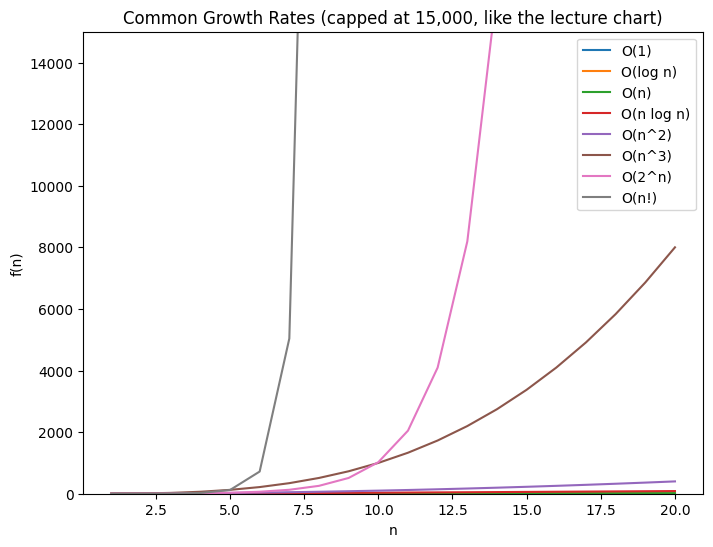

In [3]:
import matplotlib.pyplot as plt
import math

ns = list(range(1, 21))

curves = {
    "O(1)":        [1 for n in ns],
    "O(log n)":    [math.log2(n) for n in ns],
    "O(n)":        [n for n in ns],
    "O(n log n)":  [n * math.log2(n) if n > 1 else 0 for n in ns],
    "O(n^2)":      [n**2 for n in ns],
    "O(n^3)":      [n**3 for n in ns],
    "O(2^n)":      [2**n for n in ns],
    "O(n!)":       [math.factorial(n) for n in ns],
}

plt.figure(figsize=(8, 6))
for label, ys in curves.items():
    plt.plot(ns, ys, label=label)
plt.ylim(0, 15000)
plt.xlabel("n")
plt.ylabel("f(n)")
plt.title("Common Growth Rates (capped at 15,000, like the lecture chart)")
plt.legend()
plt.show()

Same story as the lecture's chart: factorial and exponential shoot off the top of
the plot almost immediately, quadratic and cubic climb noticeably, and linear/log-linear/logarithmic
stay near the bottom of the visible range even out at `n=20`. This is *why* an O(n²) algorithm that
looks "fine" on 100 items can become unusable on 100,000 - the curve isn't just a little steeper,
it's a completely different shape.

## Exercise 1: What's the Time Complexity of `isElement`?

The lecture's first "guess the complexity" example - a linear search through an unsorted array:

```
isElement(A, n, x)
    isElm = False
    for i=0 to i=n-1
        if A[i] == x
            isElm = True
    return isElm
```

Notice it does **not** stop early when it finds `x` (no `break`) - it always scans every single
element, which the slides even show as a version using a `for elm in A:` loop instead of index-based
access. Worst case (item missing, or it's the last element): the loop body runs exactly `n` times ->
`O(n)`.

Rather than just trust the formula, let's *prove* it by literally counting the comparisons the
function makes, for a range of input sizes, and checking that the comparison count grows in a
straight line with `n` (that straight line **is** what "linear" / O(n) means).

In [4]:
def is_element(A, x):
    comparisons = 0
    found = False
    for elm in A:
        comparisons += 1     # this is the "step" we're counting
        if elm == x:
            found = True
    return found, comparisons


# Worst case: search for something that ISN'T in the list, so every element gets compared
sizes = [10, 100, 1000, 10000, 100000]
for n in sizes:
    A = list(range(n))
    _, comparisons = is_element(A, -1)     # -1 is never in A -> forces the full scan
    print(f"n={n:>7}   comparisons={comparisons:>7}   comparisons/n={comparisons/n}")

n=     10   comparisons=     10   comparisons/n=1.0
n=    100   comparisons=    100   comparisons/n=1.0
n=   1000   comparisons=   1000   comparisons/n=1.0
n=  10000   comparisons=  10000   comparisons/n=1.0
n= 100000   comparisons= 100000   comparisons/n=1.0


`comparisons/n` comes out to exactly `1.0` at every size - the comparison count
*is* `n`, dead on. That's about as clean a confirmation of O(n) as you can get empirically: doubling
`n` exactly doubles the work, every time, with zero curvature.

## Exercise 2: `unique` vs. `uniqueImproved`

The lecture's classic O(n²) example, checking whether an array has any duplicate values:

```
unique(A, n)
    isUnique = true
    for i = 0 to n-1
        for j = 0 to n-1
            if i != j and A[i] == A[j]
                isUnique = false
    return isUnique
```

Every element gets compared against *every other* element - `n` choices for `i` times `n` choices
for `j` -> `n * n = n²` comparisons -> `O(n²)`.

The lecture's `uniqueImproved` version is smarter about *which* pairs it checks:

```
uniqueImproved(A, n)
    isUnique = true
    for i = 0 to n-2
        for j = i+1 to n-1
            if A[i] == A[j]
                isUnique = false
    return isUnique
```

Instead of checking every `(i, j)` pair twice (once as `(i,j)`, once again as `(j,i)`) and also
wastefully checking `i == j` and skipping it, `j` only ever runs *ahead* of `i`. Each pair gets
checked exactly once. That halves the constant factor - but it's still fundamentally comparing
every element against every other one, so the *shape* of the growth curve doesn't change: still
`O(n²)`, just with roughly half the comparisons.

In [5]:
def unique(A):
    comparisons = 0
    is_unique = True
    for i in range(len(A)):
        for j in range(len(A)):
            comparisons += 1
            if i != j and A[i] == A[j]:
                is_unique = False
    return is_unique, comparisons


def unique_improved(A):
    comparisons = 0
    is_unique = True
    for i in range(len(A)):
        for j in range(i + 1, len(A)):
            comparisons += 1
            if A[i] == A[j]:
                is_unique = False
    return is_unique, comparisons


sizes = [10, 20, 40, 80, 160]
print(f"{'n':>5} {'unique':>10} {'uniqueImproved':>16} {'ratio':>8}")
for n in sizes:
    A = list(range(n))     # all distinct -> worst case, every comparison actually runs
    _, c1 = unique(A)
    _, c2 = unique_improved(A)
    print(f"{n:>5} {c1:>10} {c2:>16} {c1/c2:>8.2f}")

    n     unique   uniqueImproved    ratio
   10        100               45     2.22
   20        400              190     2.11
   40       1600              780     2.05
   80       6400             3160     2.03
  160      25600            12720     2.01


The ratio between the two sits right around `2.0` at every size - `uniqueImproved`
is consistently doing about half the comparisons of `unique`, confirming "smaller constant, same
shape." Now let's confirm the *shape itself* is really quadratic: if you double `n`, an O(n²)
algorithm's work should roughly **quadruple** (2² = 4), not just double.

In [6]:
sizes = [50, 100, 200, 400]
prev = None
for n in sizes:
    A = list(range(n))
    _, comparisons = unique_improved(A)
    ratio_to_prev = comparisons / prev if prev else None
    print(f"n={n:>4}   comparisons={comparisons:>7}   comparisons/n^2={comparisons/n**2:.3f}"
          + (f"   growth when n doubled: x{ratio_to_prev:.2f}" if ratio_to_prev else ""))
    prev = comparisons

n=  50   comparisons=   1225   comparisons/n^2=0.490
n= 100   comparisons=   4950   comparisons/n^2=0.495   growth when n doubled: x4.04
n= 200   comparisons=  19900   comparisons/n^2=0.497   growth when n doubled: x4.02
n= 400   comparisons=  79800   comparisons/n^2=0.499   growth when n doubled: x4.01


Every time `n` doubles, the comparison count grows by roughly **4x** (2 squared) -
that's the fingerprint of O(n²). And `comparisons/n²` settles down to a constant (~0.5, since
`uniqueImproved` checks `n(n-1)/2` pairs) instead of drifting up or down as `n` grows - which is
exactly what "the growth rate is `n²`" means in practice.

## Exercise 3: Two Tricky Nested-Loop Puzzles

Two lecture puzzles where the *outer* loop condition isn't a simple `i < n` - so you can't just say
"outer runs n times" and multiply. You have to work out how many times the outer loop actually
fires first.

**Puzzle A:**
```
i = 1
while i*i <= n
    for j=0 to n
        print "hello"
    i = i + 1
```
The outer loop keeps going as long as `i*i <= n`, i.e. as long as `i <= sqrt(n)`. So the outer loop
runs about `sqrt(n)` times, not `n` times. Each of those times, the inner loop still does `n` work.
Total: `sqrt(n) * n = n^1.5` -> **O(n^1.5)**, sitting strictly between linear and quadratic.

**Puzzle B:**
```
i = 1
while 2^i <= n
    for j=0 to n
        print "goodbye"
    i = i + 1
```
Here the outer loop keeps going as long as `2^i <= n`, i.e. `i <= log2(n)`. So the outer loop only
runs about `log2(n)` times - even fewer! Total: `log2(n) * n` -> **O(n log n)**, the same class as
efficient sorting algorithms.

Let's verify both by literally running the loops and counting how many times `print` would fire,
then compare that count against the `n^1.5` and `n log n` predictions.

In [7]:
import math


def puzzle_a_count(n):
    """while i*i <= n: for j in range(n+1): ..."""
    i = 1
    total = 0
    while i * i <= n:
        for j in range(n + 1):
            total += 1
        i += 1
    return total


def puzzle_b_count(n):
    """while 2**i <= n: for j in range(n+1): ..."""
    i = 1
    total = 0
    while 2 ** i <= n:
        for j in range(n + 1):
            total += 1
        i += 1
    return total


print(f"{'n':>6} {'actual A':>10} {'n^1.5':>10} {'A/n^1.5':>9}   {'actual B':>10} {'n*log2(n)':>10} {'B/(n log n)':>12}")
for n in [100, 400, 1600, 6400, 25600]:
    a = puzzle_a_count(n)
    b = puzzle_b_count(n)
    predicted_a = n ** 1.5
    predicted_b = n * math.log2(n)
    print(f"{n:>6} {a:>10} {predicted_a:>10.0f} {a/predicted_a:>9.2f}   "
          f"{b:>10} {predicted_b:>10.0f} {b/predicted_b:>12.2f}")

     n   actual A      n^1.5   A/n^1.5     actual B  n*log2(n)  B/(n log n)
   100       1010       1000      1.01          606        664         0.91
   400       8020       8000      1.00         3208       3458         0.93
  1600      64040      64000      1.00        16010      17030         0.94
  6400     512080     512000      1.00        76812      80921         0.95
 25600    4096160    4096000      1.00       358414     374883         0.96


Both ratio columns settle into a stable constant as `n` grows (they don't keep
drifting up or down), which is exactly the empirical signature of "this really is the predicted
growth rate, just scaled by some constant." Puzzle A tracks `n^1.5` (a growth rate between linear and
quadratic - `sqrt(n)` outer iterations x `n` inner work each), and puzzle B tracks `n log n` (only
`log2(n)` outer iterations, since doubling exhausts the budget `2^i <= n` so much faster than
counting up by 1 does).

## Exercise 4: A Function of Two Variables

Last lecture example - what happens when the input isn't just "one array of size n" but *two*
independent arrays?

```
ArrayWithBiggestSum(A, an, B, bn)
    sumA = ArraySum(A, an)
    sumB = ArraySum(B, bn)
    if sumA >= sumB
        return sumA
    else
        return sumB
```

`ArraySum` is the very first example from this notebook - it's `O(n)` for an array of size `n`. Here
we call it once on an array of size `an` and once on an array of size `bn`. Since `an` and `bn` are
*independent* sizes (one array could be huge while the other is tiny), you can't collapse this into
a single-variable `O(n)` - the honest answer is `O(an + bn)`.

This matters in practice: if you carelessly wrote this as "O(n)" using just one `n`, you'd be
hiding the fact that the cost genuinely depends on *two* separate things that can grow
independently.

In [8]:
def array_with_biggest_sum(A, B):
    steps = 0

    sum_a = 0
    for x in A:
        sum_a += x
        steps += 1        # one step per element of A

    sum_b = 0
    for x in B:
        sum_b += x
        steps += 1        # one step per element of B

    return max(sum_a, sum_b), steps


# Prove the step count really is (len(A) + len(B)), independent of how the two sizes are split
cases = [(5, 5), (10, 1000), (1000, 10), (500, 500)]
for an, bn in cases:
    A = list(range(an))
    B = list(range(bn))
    _, steps = array_with_biggest_sum(A, B)
    print(f"len(A)={an:>5}  len(B)={bn:>5}   steps={steps:>5}   an+bn={an+bn:>5}   matches={steps == an + bn}")

len(A)=    5  len(B)=    5   steps=   10   an+bn=   10   matches=True
len(A)=   10  len(B)= 1000   steps= 1010   an+bn= 1010   matches=True
len(A)= 1000  len(B)=   10   steps= 1010   an+bn= 1010   matches=True
len(A)=  500  len(B)=  500   steps= 1000   an+bn= 1000   matches=True


`steps` always equals `an + bn` exactly, no matter how lopsided the two sizes are
(`10 + 1000` gives the same step count as `1000 + 10`, and both differ from `500 + 500` even though
`an + bn = 1010` vs `1000` are close) - there's genuinely no way to squash this into a single
variable without losing information, which is exactly why the honest complexity is `O(an + bn)`
rather than just `O(n)`.